# basic 

In [1]:
%load_ext autoreload
%autoreload all

In [2]:
import polars as pl
import numpy as np
import pickle
import tqdm 
import src.configs_new_mapped as configs_mapped
import src.graph_fct as graph_fct
import src.new_tokenizer as new_tokenizer
import os
import multiprocessing as mp
from src import eval as tokeval


In [3]:
df = pl.read_parquet(configs_mapped.GraphConfig().concept_path).select("id", "label")
id_to_label = dict(zip(df["id"], df["label"]))

with open(configs_mapped.ProcessedGraph().combined_subgraphs, "rb") as f:
    combined_subgraphs = pickle.load(f)


df_mapped = pl.read_parquet(configs_mapped.ProcessedGraph().mapped_cpts)
mapped_ids = df_mapped["id"].to_list()
   
Ks = np.arange(500, 12_000, 500)

candidate_cols_set =set(["token", "candidate", "candidate_id", "dst.id", "candidate"])

# apply tokenizer and eval

In [4]:
import os
import multiprocessing as mp

all_candidates = configs_mapped.CandidateLists().all_candidate_to_test
results = []

tasks = []
for category, file_list in all_candidates.items():
    for file_type, file in file_list.items():
        if file_type == "k_random_all_samples":
            continue
        df = pl.read_parquet(file)
        candidate_col = list(set(df.columns).intersection(candidate_cols_set))[0]
        for k in Ks:
            candidates = df.head(k)[candidate_col].to_list()
            tasks.append(((category, file_type, k), candidates))

n_workers = os.cpu_count()
with mp.Pool(n_workers, initializer=new_tokenizer._init_coverage_worker,
             initargs=(combined_subgraphs, mapped_ids, 3, id_to_label)) as pool:
    for i, ((category, file_type, k), metrics) in enumerate(pool.imap_unordered(new_tokenizer._worker_coverage_score, tasks, chunksize=4), 1):
        results.append({
            "category": category,
            "file_type": file_type,
            "k": k,
            **metrics,
        })
        if i % 50 == 0 or i == len(tasks):
            print(f"{i}/{len(tasks)}")

results_df = pl.DataFrame(results)
results_df


50/253
100/253
150/253
200/253
250/253
253/253


category,file_type,k,conciseness,distance_score,uniqueness_entropy,unk_rate,tree_complexity,exact_rate,semantic_coverage
str,str,i64,f64,f64,f64,f64,f64,f64,f64
"""lazy_new""","""lazy_greedy_08""",1000,6.004052,1.814793,0.936258,0.607541,5.966002,0.00507,0.883968
"""lazy_new""","""lazy_greedy_08""",1500,6.327692,1.743674,0.948824,0.529426,5.762427,0.007887,0.920818
"""lazy_new""","""lazy_greedy_08""",2000,6.48377,1.684135,0.957574,0.467107,5.593326,0.011333,0.941752
"""lazy_new""","""lazy_greedy_08""",2500,6.499675,1.629703,0.961411,0.420412,5.462145,0.015601,0.955036
"""lazy_new""","""lazy_greedy""",500,6.255688,2.175802,0.910602,0.744659,6.813348,0.001993,0.815411
…,…,…,…,…,…,…,…,…,…
"""baseline""","""most_children""",9000,6.806024,1.777397,0.948512,0.503835,5.735428,0.053586,0.917547
"""baseline""","""most_children""",9500,6.823684,1.756623,0.949795,0.472893,5.650336,0.056555,0.926554
"""baseline""","""most_children""",10000,6.834865,1.743637,0.950766,0.450206,5.619978,0.059393,0.933173


In [5]:
results_df

category,file_type,k,conciseness,distance_score,uniqueness_entropy,unk_rate,tree_complexity,exact_rate,semantic_coverage
str,str,i64,f64,f64,f64,f64,f64,f64,f64
"""lazy_new""","""lazy_greedy_08""",1000,6.004052,1.814793,0.936258,0.607541,5.966002,0.00507,0.883968
"""lazy_new""","""lazy_greedy_08""",1500,6.327692,1.743674,0.948824,0.529426,5.762427,0.007887,0.920818
"""lazy_new""","""lazy_greedy_08""",2000,6.48377,1.684135,0.957574,0.467107,5.593326,0.011333,0.941752
"""lazy_new""","""lazy_greedy_08""",2500,6.499675,1.629703,0.961411,0.420412,5.462145,0.015601,0.955036
"""lazy_new""","""lazy_greedy""",500,6.255688,2.175802,0.910602,0.744659,6.813348,0.001993,0.815411
…,…,…,…,…,…,…,…,…,…
"""baseline""","""most_children""",9000,6.806024,1.777397,0.948512,0.503835,5.735428,0.053586,0.917547
"""baseline""","""most_children""",9500,6.823684,1.756623,0.949795,0.472893,5.650336,0.056555,0.926554
"""baseline""","""most_children""",10000,6.834865,1.743637,0.950766,0.450206,5.619978,0.059393,0.933173


In [6]:
all_candidates = configs_mapped.CandidateLists().all_candidate_to_test
category = "baseline"
file_type = "k_random_all_samples"

results = []
df = pl.read_parquet(all_candidates[category][file_type])
candidate_col = list(set(df.columns).intersection(candidate_cols_set))[0]

iter_list = list(df["iter"].unique())

tasks = [
    ((k, it), df.filter((pl.col("iter") == it) & (pl.col("k") == k))[candidate_col].to_list())
    for k in Ks
    for it in iter_list
]

n_workers = os.cpu_count()
with mp.Pool(n_workers, initializer=new_tokenizer._init_coverage_worker,
             initargs=(combined_subgraphs, mapped_ids, 3, id_to_label)) as pool:
    for i, ((k, it), metrics) in enumerate(pool.imap_unordered(new_tokenizer._worker_coverage_score, tasks, chunksize=4), 1):
        results.append({
            "category": category,
            "file_type": file_type,
            "iter": it,
            "k": k,
            **metrics,
        })
        if i % 50 == 0 or i == len(tasks):
            print(f"{i}/{len(tasks)}")

metric_cols = ["conciseness", "distance_score", "uniqueness_entropy", "unk_rate", "tree_complexity", "exact_rate", "semantic_coverage"]
results_df_rnd_k = pl.DataFrame(results)
results_df_rnd_k = results_df_rnd_k.group_by("category", "file_type", "k").agg([pl.col(c).mean() for c in metric_cols])


50/1150
100/1150
150/1150
200/1150
250/1150
300/1150
350/1150
400/1150
450/1150
500/1150
550/1150
600/1150
650/1150
700/1150
750/1150
800/1150
850/1150
900/1150
950/1150
1000/1150
1050/1150
1100/1150
1150/1150


In [8]:
pl.concat([results_df_rnd_k, results_df]).write_parquet(configs_mapped.Result().metrics_result)

# plot result

In [12]:
df_result_metrics = pl.read_parquet(configs_mapped.Result().metrics_result).filter(pl.col("file_type")!="k_random_all_samples")
df_result_metrics

category,file_type,k,conciseness,distance_score,uniqueness_entropy,unk_rate,tree_complexity,exact_rate,semantic_coverage
str,str,i64,f64,f64,f64,f64,f64,f64,f64
"""lazy_new""","""lazy_greedy_08""",1000,6.004052,1.814793,0.936258,0.607541,5.966002,0.00507,0.883968
"""lazy_new""","""lazy_greedy_08""",1500,6.327692,1.743674,0.948824,0.529426,5.762427,0.007887,0.920818
"""lazy_new""","""lazy_greedy_08""",2000,6.48377,1.684135,0.957574,0.467107,5.593326,0.011333,0.941752
"""lazy_new""","""lazy_greedy_08""",2500,6.499675,1.629703,0.961411,0.420412,5.462145,0.015601,0.955036
"""lazy_new""","""lazy_greedy""",500,6.255688,2.175802,0.910602,0.744659,6.813348,0.001993,0.815411
…,…,…,…,…,…,…,…,…,…
"""baseline""","""most_children""",9000,6.806024,1.777397,0.948512,0.503835,5.735428,0.053586,0.917547
"""baseline""","""most_children""",9500,6.823684,1.756623,0.949795,0.472893,5.650336,0.056555,0.926554
"""baseline""","""most_children""",10000,6.834865,1.743637,0.950766,0.450206,5.619978,0.059393,0.933173


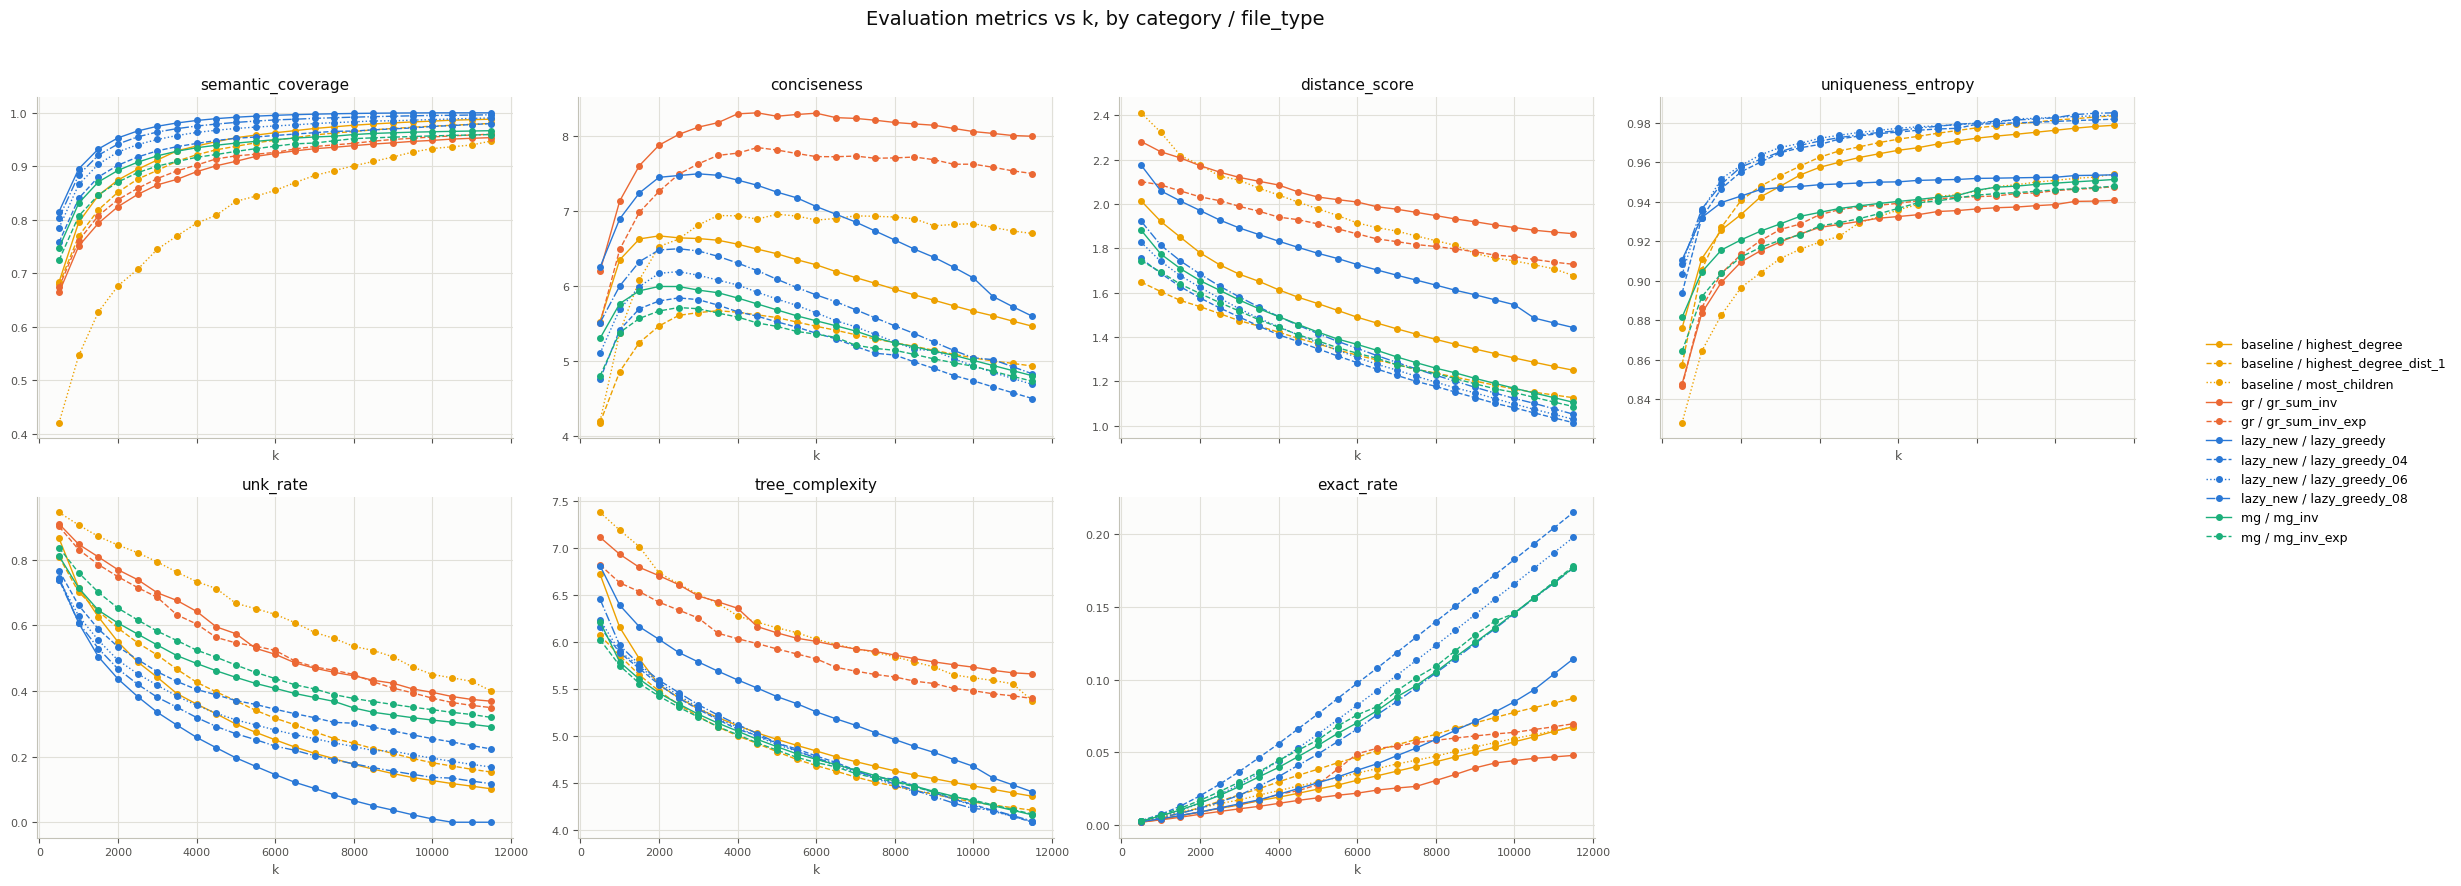

In [15]:
import matplotlib.pyplot as plt

metric_cols = ["semantic_coverage", "conciseness", "distance_score", "uniqueness_entropy",
               "unk_rate", "tree_complexity", "exact_rate"]

# categorical hues (fixed order, validated for CVD-safe adjacent pairs) -- one per `category`
category_colors = {
    "lazy_new": "#2a78d6",   # blue
    "gr":       "#eb6834",   # orange
    "mg":       "#1baf7a",   # aqua
    "baseline": "#eda100",   # yellow
}
linestyles_cycle = ["-", "--", ":", "-."]   # secondary encoding for file_type within a category

combos = (
    df_result_metrics
    .select("category", "file_type")
    .unique()
    .sort(["category", "file_type"])
    .to_dicts()
)

file_type_style = {}
for combo in combos:
    cat, ft = combo["category"], combo["file_type"]
    styles = file_type_style.setdefault(cat, {})
    styles[ft] = linestyles_cycle[len(styles) % len(linestyles_cycle)]

fig, axes = plt.subplots(2, 4, figsize=(22, 9), sharex=True)
axes = axes.flatten()

for ax, metric in zip(axes, metric_cols):
    for combo in combos:
        cat, ft = combo["category"], combo["file_type"]
        sub = df_result_metrics.filter((pl.col("category") == cat) & (pl.col("file_type") == ft)).sort("k")
        ax.plot(sub["k"], sub[metric],
                color=category_colors[cat], linestyle=file_type_style[cat][ft],
                linewidth=1, marker="o", markersize=4, label=f"{cat} / {ft}")
    ax.set_title(metric, fontsize=11, color="#0b0b0b")
    ax.set_xlabel("k", fontsize=9, color="#52514e")
    ax.tick_params(colors="#52514e", labelsize=8)
    ax.grid(True, color="#e1e0d9", linewidth=0.8)
    ax.set_facecolor("#fcfcfb")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#c3c2b7")
    ax.spines["bottom"].set_color("#c3c2b7")

for ax in axes[len(metric_cols):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False)
fig.suptitle("Evaluation metrics vs k, by category / file_type", fontsize=14, color="#0b0b0b")
fig.tight_layout(rect=[0, 0, 0.98, 0.96])
plt.show()